<a href="https://colab.research.google.com/github/piolin666satan/26_b2_r1/blob/main/Analitica1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

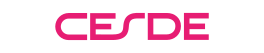

In [ ]:
from IPython.display import SVG, display
import requests

# Obtenemos el contenido del SVG desde la URL
url = "https://www.cesde.edu.co/wp-content/uploads/2023/02/logo-Cesde-2023.svg"
response = requests.get(url)

# Lo mostramos
display(SVG(response.content))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Subir el archivo a Google Colab
Antes de ejecutar el código, el archivo debe existir en la máquina virtual. Tienes dos formas rápidas:

Manual: Haz clic en el icono de la carpeta en la barra lateral izquierda de Colab y arrastra tu archivo accidentalidad.csv allí.

In [ ]:
from google.colab import files
uploaded = files.upload()

2. Verificar la ruta (Path)
Por defecto, cuando subes un archivo manualmente, queda en la ruta /content/. Si quieres que la ruta sea local/data/accidentalidad.csv como en tu ejemplo, debes crear esas carpetas primero:

In [ ]:
# Crear la estructura de carpetas en la terminal de Colab
!mkdir -p local/data
# Mover el archivo (asumiendo que lo subiste a la raíz)
!mv accidentalidad.csv local/data/

mv: cannot stat 'accidentalidad.csv': No such file or directory


3. Leer el archivo con Spark
Una vez el archivo está en la ruta correcta, el comando sc.textFile lo reconocerá. Ten en cuenta que sc.textFile crea un RDD (Resilient Distributed Dataset), que es la estructura básica de Spark.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()

# Leer como DataFrame (más potente para archivos CSV)
df = spark.read.csv("local/data/accidentalidad.csv", header=True, inferSchema=True)
# Muestra una lista de tuplas: [('columna', 'tipo'), ...]
df.printSchema()
df.show(5)
df.count()

root
 |-- RADICADO: double (nullable = true)
 |-- FECHA: string (nullable = true)
 |-- HORA: timestamp (nullable = true)
 |-- DIA: string (nullable = true)
 |-- CLASE: string (nullable = true)
 |-- DIRECCION: string (nullable = true)
 |-- TIPO_GEOCOD: string (nullable = true)
 |-- GRAVEDAD: string (nullable = true)
 |-- BARRIO: string (nullable = true)
 |-- COMUNA: string (nullable = true)
 |-- DISENO: string (nullable = true)

+---------+----------+-------------------+---------+---------+-----------+----------------+----------+------------+---------------+------------+
| RADICADO|     FECHA|               HORA|      DIA|    CLASE|  DIRECCION|     TIPO_GEOCOD|  GRAVEDAD|      BARRIO|         COMUNA|      DISENO|
+---------+----------+-------------------+---------+---------+-----------+----------------+----------+------------+---------------+------------+
|1565221.0|01/01/2017|2026-03-21 00:10:00|DOMINGO  |Atropello|CL 68 CR 87|EPM con Interior|    HERIDO|    Palenque|        Robledo|Tr

42558

Este código es la forma moderna y estándar de trabajar con Spark SQL. A diferencia del sc.textFile que genera un RDD (datos crudos, línea por línea), este método crea un DataFrame, que organiza los datos en tablas con filas y columnas, de forma muy similar a Excel o SQL.

**SparkSession:** Es el punto de entrada para programar con Spark. En versiones antiguas se usaba SparkContext, pero la "Sesión" es más potente porque unifica todas las funcionalidades (SQL, Streaming, etc.).

**.builder:** Inicia un configurador para tu sesión.

**.master("local[*]"):**  Define dónde se ejecutará el trabajo. El valor "local[*]" le dice a Spark: "Usa todos los núcleos (procesadores) disponibles en esta máquina virtual de Colab". Esto permite procesar datos en paralelo.

**.getOrCreate():** Si ya existe una sesión abierta, la recupera; si no, crea una nueva. Evita errores de duplicidad.



Aquí es donde ocurre la "magia" de los DataFrames. Spark no solo lee el archivo, sino que lo interpreta:

**header=True:** Le indica a Spark que la primera fila del archivo contiene los nombres de las columnas (ej: "Fecha", "Barrio", "Tipo de Accidente"). Si no pones esto, Spark tratará los títulos como si fueran datos reales.

**inferSchema=True:** Es fundamental. Sin esto, Spark lee todo como si fuera texto (String). Al activarlo, Spark analiza los datos y deduce automáticamente si una columna es de números enteros, decimales o fechas.
**.show(5):** Imprime en pantalla una tabla estética con las primeras 5 filas del archivo. Es la mejor forma de verificar que los datos se cargaron correctamente y que las columnas están alineadas.

# **Haz una investigación en 5 minutos de por qué es importante Spark, y responde con tus palabras**

Ventajas en Analítica de Datos
¿Por qué los científicos de datos lo aman? Aquí las razones clave:

Velocidad (In-Memory Computing): A diferencia de Hadoop, que escribe datos en el disco duro constantemente, Spark procesa casi todo en la memoria RAM, lo que lo hace hasta 100 veces más rápido en ciertas tareas.

Escalabilidad: Empiezas en tu laptop y, con el mismo código, puedes escalar a 1,000 servidores en la nube (AWS, Azure o Google Cloud).

Tolerancia a fallos: Si uno de los nodos del cluster falla, Spark sabe exactamente qué parte del cálculo se perdió y lo reconstruye automáticamente.

Ecosistema Unificado: Puedes limpiar los datos, hacer análisis estadístico y desplegar un modelo de ML, todo dentro de la misma herramienta.

1. Curva de aprendizaje y complejidad
No es tan intuitivo como Pandas. Configurar un entorno de Spark (instalar Java, definir variables de entorno, configurar el SparkSession) es mucho más tedioso. Además, entender conceptos como Lazy Evaluation (el código no se ejecuta hasta que pides un resultado) puede confundir a los principiantes.

2. Alto consumo de recursos (RAM)
Spark tiene hambre de memoria. Como su magia reside en el procesamiento In-Memory, si no configuras bien el cluster, es muy fácil quedarse sin memoria (OutOfMemoryError). Requiere una gestión cuidadosa de cómo se reparten los recursos entre los nodos.

3. El "Small File Problem"
Spark está diseñado para mover montañas. Si intentas usarlo para procesar miles de archivos muy pequeños (de pocos KB), el rendimiento será peor que el de una base de datos tradicional o incluso que un script de Python simple. Spark gasta más tiempo "organizando" las tareas que procesando los datos pequeños.

4. Latencia en tiempo real
Aunque mencioné que sirve para Streaming, Spark Structured Streaming funciona mediante micro-batches (pequeños lotes de segundos). Si necesitas una latencia de milisegundos reales (como en trading de alta frecuencia), herramientas como Apache Flink suelen ser mejores opciones.

5. Depuración (Debugging) difícil
Cuando algo falla en un sistema distribuido, leer los logs es una pesadilla. El error puede haber ocurrido en el "Worker 45" de un cluster de 100 máquinas, y descifrar el mensaje de error de Java/Scala a través de PySpark puede ser muy frustrante.

# **Operaciones de Limpieza y Transformación**

Convertir Fechas y Horas
Por defecto, Spark lee la fecha como una cadena de texto. Es mejor convertirla a un tipo Date para hacer filtros temporales.

In [ ]:
from pyspark.sql.functions import to_date, col

# Convertir la columna FECHA al formato de fecha de Spark
df = df.withColumn("FECHA_DT", to_date(col("FECHA"), "dd/MM/yyyy"))
df.show(2)

+---------+----------+-------------------+---------+---------+-----------+----------------+--------+------------+----------+------------+----------+
| RADICADO|     FECHA|               HORA|      DIA|    CLASE|  DIRECCION|     TIPO_GEOCOD|GRAVEDAD|      BARRIO|    COMUNA|      DISENO|  FECHA_DT|
+---------+----------+-------------------+---------+---------+-----------+----------------+--------+------------+----------+------------+----------+
|1565221.0|01/01/2017|2026-03-21 00:10:00|DOMINGO  |Atropello|CL 68 CR 87|EPM con Interior|  HERIDO|    Palenque|   Robledo|Tramo de via|2017-01-01|
|1565189.0|01/01/2017|2026-03-21 00:20:00|DOMINGO  |   Choque|CL 44 CR 93|EPM sin Interior|  HERIDO|Campo Alegre|La América|Tramo de via|2017-01-01|
+---------+----------+-------------------+---------+---------+-----------+----------------+--------+------------+----------+------------+----------+
only showing top 2 rows


# **Resumen Estadístico**

Filtrar Accidentes con Fatalidades
Si necesitas analizar los casos más críticos, puedes filtrar por la columna GRAVEDAD:

In [ ]:
# Filtrar solo accidentes con personas fallecidas
muertos_df = df.filter(col("GRAVEDAD") == "MUERTO")
muertos_df.show()
muertos_df.count()

+---------+----------+-------------------+---------+------------------+--------------------+--------------------+--------+--------------------+--------------------+------+----------+
| RADICADO|     FECHA|               HORA|      DIA|             CLASE|           DIRECCION|         TIPO_GEOCOD|GRAVEDAD|              BARRIO|              COMUNA|DISENO|  FECHA_DT|
+---------+----------+-------------------+---------+------------------+--------------------+--------------------+--------+--------------------+--------------------+------+----------+
|     12.0|01/01/2017|2026-03-21 05:05:00|DOMINGO  |         Atropello|       CL 77 A CR 88|          Malla vial|  MUERTO|          Aures No.1|             Robledo|   S/I|2017-01-01|
|     20.0|01/01/2017|2026-03-21 08:30:00|DOMINGO  |            Choque| CL 66 CR 103 B - 15|Nomenclatura con ...|  MUERTO|Área de Expansión...|Corregimiento de ...|   S/I|2017-01-01|
|   1122.0|01/01/2017|2026-03-21 21:23:00|DOMINGO  |         Atropello|CR 65 C CL 105

149

Conteo de accidentes por clase para entender cuáles son los más comunes

In [ ]:
from pyspark.sql.functions import col, count, desc, substring, month, to_date, when, isnan
df.groupBy("CLASE").count().orderBy("count", ascending=False).show()

+------------------+-----+
|             CLASE|count|
+------------------+-----+
|            Choque|29190|
|              Otro| 4718|
|         Atropello| 3638|
|    Caida Ocupante| 3423|
|       Volcamiento| 1572|
|    Caída Ocupante|    9|
|          Incendio|    4|
|           Choque |    3|
|Choque y Atropello|    1|
+------------------+-----+



Top 5 de Comunas con mayor accidentalidad

In [ ]:
df.groupBy("COMUNA").count().orderBy(desc("count")).limit(5).show()

+----------------+-----+
|          COMUNA|count|
+----------------+-----+
|   La Candelaria| 8457|
|Laureles Estadio| 4917|
|        Castilla| 4444|
|      El Poblado| 3853|
|        Guayabal| 3233|
+----------------+-----+



**Distribución de accidentes por Gravedad**
Útil para saber cuántos accidentes resultaron en heridos, muertos o solo daños materiales.

In [ ]:
df.groupBy("GRAVEDAD").count().show()

+----------+-----+
|  GRAVEDAD|count|
+----------+-----+
|    HERIDO|22865|
|CON MUERTO|   73|
|SOLO DAÑOS|19471|
|    MUERTO|  149|
+----------+-----+



**Accidentes por día de la semana**
¿Son los fines de semana más peligrosos? Esta consulta te lo dirá.

In [ ]:
df.groupBy("DIA").count().orderBy(desc("count")).show()

+---------+-----+
|      DIA|count|
+---------+-----+
|VIERNES  | 6909|
|MARTES   | 6817|
|MIÉRCOLES| 6604|
|JUEVES   | 6275|
|SÁBADO   | 6055|
|LUNES    | 5981|
|DOMINGO  | 3917|
+---------+-----+



**Análisis de accidentes por franja horaria**
Extraemos la hora de la columna HORA para ver en qué momento del día ocurren más incidentes.

In [ ]:
santiago = df.withColumn("HORA_SOLA", substring(col("HORA"), 12,2)) \
  .groupBy("HORA_SOLA").count() \
  .orderBy("HORA_SOLA").orderBy(desc("count"))
santiago.show()

+---------+-----+
|HORA_SOLA|count|
+---------+-----+
|       17| 3116|
|       16| 2819|
|       12| 2799|
|       18| 2742|
|       15| 2669|
|       13| 2656|
|       14| 2636|
|       07| 2471|
|       19| 2388|
|       06| 2288|
|       11| 2284|
|       08| 2058|
|       10| 2055|
|       20| 1906|
|       09| 1905|
|       21| 1584|
|       22| 1116|
|       05| 1039|
|       23|  629|
|       04|  347|
+---------+-----+
only showing top 20 rows


**Tendencia mensual de accidentes**
Si ya convertiste la fecha a tipo Date, puedes agrupar por mes para ver estacionalidad (ej. ¿aumentan en diciembre?).

In [ ]:
from pyspark.sql.functions import month, col, desc

Santiagodos = df.withColumn("MES", month(col("FECHA_DT"))) \
  .groupBy("MES").count()

print("Accidentes por mes (ordenado por mes):")
Santiagodos.orderBy("MES").show()

print("\nAccidentes por mes (ordenado por cantidad descendente):")
Santiagodos.orderBy(desc("count")).show()

Accidentes por mes (ordenado por mes):
+----+-----+
| MES|count|
+----+-----+
|NULL|25811|
|   1|  964|
|   2| 1455|
|   3| 1401|
|   4| 1462|
|   5| 1481|
|   6| 1460|
|   7| 1300|
|   8| 1614|
|   9| 1527|
|  10| 1390|
|  11| 1287|
|  12| 1406|
+----+-----+


Accidentes por mes (ordenado por cantidad descendente):
+----+-----+
| MES|count|
+----+-----+
|NULL|25811|
|   8| 1614|
|   9| 1527|
|   5| 1481|
|   4| 1462|
|   6| 1460|
|   2| 1455|
|  12| 1406|
|   3| 1401|
|  10| 1390|
|   7| 1300|
|  11| 1287|
|   1|  964|
+----+-----+



**Porcentaje de participación por Gravedad**
Calcula qué proporción del total representan los accidentes con heridos.

In [ ]:
total_accidentes = df.count()
df.groupBy("GRAVEDAD") \
  .count() \
  .withColumn("PORCENTAJE", (col("count") / total_accidentes) * 100) \
  .show()

+----------+-----+-------------------+
|  GRAVEDAD|count|         PORCENTAJE|
+----------+-----+-------------------+
|    HERIDO|22865|  53.72667888528596|
|CON MUERTO|   73|0.17153061704027445|
|SOLO DAÑOS|19471| 45.751680060153205|
|    MUERTO|  149| 0.3501104375205602|
+----------+-----+-------------------+



# **Ejercicio**

El presente ejercicio tiene como objetivo poner en práctica las habilidades de manipulación de datos a gran escala utilizando el motor de procesamiento Apache Spark. Para ello, trabajaremos con el archivo hurtos.csv, el cual contiene registros detallados de incidentes de seguridad en diferentes departamentos y municipios.

Los estudiantes deberán cargar el archivo en un DataFrame de Spark, asegurando la correcta inferencia de tipos y el manejo de encabezados. A partir de esta carga, se deberán resolver las siguientes 20 preguntas de negocio y técnica, entregando el código Python correspondiente y los resultados obtenidos. Este análisis permitirá identificar patrones geográficos, temporales y perfiles de víctimas en el territorio nacional.

**Tips para los estudiantes:**

Para la pregunta 9, recuerda importar from pyspark.sql.functions import substring, col.

Para los rankings, utiliza groupBy().count().orderBy(desc("count")).

Para los filtros específicos (como Bogotá o Antioquia), recuerda que los nombres en el CSV suelen estar en MAYÚSCULAS.

1. Conteo Total: ¿Cuál es la cantidad total de filas (registros) que contiene el archivo hurtos.csv?

2. Esquema: Muestra la estructura del DataFrame (schema). ¿Qué columnas fueron detectadas como Strings y cuáles como Integers?

3. Calidad de Datos: ¿Existen valores nulos en las columnas DEPARTAMENTO, MUNICIPIO o HORA? Realiza un conteo por columna.

4. Limpieza: ¿Cuántos registros tienen una edad reportada como 0 o valores no numéricos?

5. Departamentos: ¿Cuáles son los 5 departamentos con mayor número de reportes?

6. Municipios: Dentro del departamento de Antioquia, ¿cuáles son los 3 municipios con más hurtos registrados?

7. Zonas: ¿Qué porcentaje de los hurtos ocurren en zona URBANA frente a la zona RURAL?

8. Día de la semana: ¿Cuál es el día de la semana (Lunes, Martes, etc.) donde se registran más incidentes?

9. Franja Horaria: Crea una columna llamada HORA_SOLA (usando substring) y determina en qué hora del día (00 a 23) ocurren más hurtos.

10. Análisis de Madrugada: ¿Cuántos hurtos ocurren entre las 00:00 y las 04:00 AM?

11. Armas Empleadas: Haz un ranking de las "Armas" o métodos más utilizados por los agresores.

12. Movilidad del Agresor: ¿Cuál es el medio de transporte (Móvil Agresor) más común en los delitos?

13. Movilidad de la Víctima: ¿Cuántas víctimas se encontraban como "A PIE" al momento del incidente?

14. Combinación de Peligro: ¿Cuál es la combinación de "Arma Empleada" y "Móvil Agresor" que más se repite (ej. Arma de fuego + Motocicleta)?

15. Género: ¿Cuál es la distribución de hurtos por sexo (MASCULINO / FEMENINO)?

16. Edad Promedio: ¿Cuál es la edad promedio de las víctimas a nivel nacional?

17. Rango Etario: ¿Cuál es la edad de la víctima más joven y de la más longeva en el registro?

18. Menores de Edad: ¿Cuántos registros corresponden a víctimas menores de 18 años?

19. Análisis en Bogotá: Específicamente para la ciudad de BOGOTÁ D.C. (CT), ¿cuál es el arma más utilizada los fines de semana (Sábado y Domingo)?

20. Participación Relativa: De todos los hurtos cometidos con "ARMA DE FUEGO", ¿qué porcentaje ocurrieron en el departamento del VALLE?




In [5]:
from google.colab import files
uploaded = files.upload()

Saving hurtos.csv to hurtos.csv


In [6]:
# Crear la estructura de carpetas en la terminal de Colab
!mkdir -p local/data
# Mover el archivo (asumiendo que lo subiste a la raíz)
!mv hurtos.csv local/data/

In [7]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").getOrCreate()

# Leer como DataFrame (más potente para archivos CSV)
df = spark.read.csv("local/data/hurtos.csv", header=True, inferSchema=True,sep=";")

Punto 1

In [8]:
df.count()

101286

Punto 2


In [ ]:
df.printSchema()


root
 |-- DEPARTAMENTO: string (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- DIA : string (nullable = true)
 |-- HORA : timestamp (nullable = true)
 |-- ZONA: string (nullable = true)
 |-- ARMA EMPLEADA: string (nullable = true)
 |-- MOVIL AGRESOR: string (nullable = true)
 |-- MOVIL VICTIMA: string (nullable = true)
 |-- EDAD: integer (nullable = true)
 |-- SEXO: string (nullable = true)



Punto 3

In [ ]:
from pyspark.sql.functions import col, sum
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in ["DEPARTAMENTO", "MUNICIPIO", "HORA ", "DIA ","ZONA", "ARMA EMPLEADA", "MOVIL AGRESOR", "MOVIL VICTIMA", "EDAD", "SEXO" ]]).show()

+------------+---------+-----+----+----+-------------+-------------+-------------+----+----+
|DEPARTAMENTO|MUNICIPIO|HORA |DIA |ZONA|ARMA EMPLEADA|MOVIL AGRESOR|MOVIL VICTIMA|EDAD|SEXO|
+------------+---------+-----+----+----+-------------+-------------+-------------+----+----+
|           2|        2|    2|   2|   2|            2|            2|            2| 381|   2|
+------------+---------+-----+----+----+-------------+-------------+-------------+----+----+



Punto 4


In [ ]:
Punto4 = df.filter((col("EDAD") == 0))
Punto4.count()

1

Punto 5


In [ ]:
from pyspark.sql.functions import desc
Punto5 = df.groupBy("DEPARTAMENTO").count().orderBy(desc("count"))
Punto5.show(5)

+------------+-----+
|DEPARTAMENTO|count|
+------------+-----+
|CUNDINAMARCA|28523|
|   ANTIOQUIA|12447|
|       VALLE|12443|
|   SANTANDER| 6478|
|   ATLÁNTICO| 5572|
+------------+-----+
only showing top 5 rows


Punto 6


In [ ]:
from pyspark.sql.functions import col, desc

Punto6 = df.filter(col("DEPARTAMENTO") == "ANTIOQUIA").groupBy("MUNICIPIO").count().orderBy(desc("count"))
Punto6.show(3)

+-------------+-----+
|    MUNICIPIO|count|
+-------------+-----+
|MEDELLÍN (CT)| 7830|
|     ENVIGADO|  757|
|       ITAGUI|  681|
+-------------+-----+
only showing top 3 rows


Punto 7


In [ ]:
Punto7 = df.count(); df.groupBy("ZONA").count().withColumn("%", (col("count")/total)*100).show()

+------+-----+--------------------+
|  ZONA|count|                   %|
+------+-----+--------------------+
|  NULL|    2|0.001974606559642991|
| RURAL| 4846|   4.784471694014967|
|URBANA|96438|   95.21355369942539|
+------+-----+--------------------+



Punto 8


In [ ]:
Punto8 = df.groupBy("DIA ").count().orderBy(desc("count")).show(7)

+---------+-----+
|     DIA |count|
+---------+-----+
|  Viernes|15722|
|Miércoles|15677|
|   Jueves|15453|
|   Sábado|14906|
|   Martes|14861|
|    Lunes|13515|
|  Domingo|11150|
+---------+-----+
only showing top 7 rows


Punto 9

In [ ]:
from pyspark.sql.functions import substring, col, desc
Punto9 = df.withColumn("HORA_SOLA", substring(col("HORA "), 1, 2))
Punto9.groupBy("HORA_SOLA").count().orderBy(desc("count")).show(1)

+---------+------+
|HORA_SOLA| count|
+---------+------+
|       20|101284|
+---------+------+
only showing top 1 row


Punto 10

In [ ]:
Punto10 = Punto9.filter(col("HORA_SOLA").cast("int").between(0, 4)).count()


Punto 11

In [10]:
from pyspark.sql.functions import substring, col, desc

df.groupBy("ARMA EMPLEADA").count().orderBy(desc("count")).show()

+-------------------+-----+
|      ARMA EMPLEADA|count|
+-------------------+-----+
|SIN EMPLEO DE ARMAS|46780|
|      ARMA DE FUEGO|19818|
|        ARMA BLANCA|19226|
|       CONTUNDENTES|13502|
|       ESCOPOLAMINA|  893|
|          CORTANTES|  559|
|       NO REPORTADO|  430|
|              PERRO|   68|
|            JERINGA|    8|
|               NULL|    2|
+-------------------+-----+



Punto 12

In [11]:
from pyspark.sql.functions import substring, col, desc
df.groupBy("MOVIL AGRESOR").count().orderBy(desc("count")).limit(1).show()

+-------------+-----+
|MOVIL AGRESOR|count|
+-------------+-----+
|        A PIE|77109|
+-------------+-----+



Punto 13

In [12]:
from pyspark.sql.functions import substring, col, desc
victimas_a_pie = df.filter(col("MOVIL VICTIMA") == "A PIE").count()
print(f"Total víctimas a pie: {victimas_a_pie}")

Total víctimas a pie: 81197


Punto 14

In [13]:
from pyspark.sql.functions import substring, col, desc
df.groupBy("ARMA EMPLEADA", "MOVIL AGRESOR").count().orderBy(desc("count")).show(5)

+-------------------+--------------------+-----+
|      ARMA EMPLEADA|       MOVIL AGRESOR|count|
+-------------------+--------------------+-----+
|SIN EMPLEO DE ARMAS|               A PIE|40802|
|        ARMA BLANCA|               A PIE|15227|
|       CONTUNDENTES|               A PIE|11784|
|      ARMA DE FUEGO|               A PIE| 7692|
|      ARMA DE FUEGO|PASAJERO MOTOCICLETA| 7402|
+-------------------+--------------------+-----+
only showing top 5 rows


Punto 15

In [14]:
from pyspark.sql.functions import substring, col, desc
df.groupBy("SEXO").count().show()

+------------+-----+
|        SEXO|count|
+------------+-----+
|    FEMENINO|40499|
|        NULL|    2|
|   MASCULINO|60780|
|NO REPORTADO|    5|
+------------+-----+



Punto 16

In [17]:
from pyspark.sql.functions import substring, col, desc, avg
df.filter(col("EDAD") > 0).select(avg("EDAD").alias("Promedio_Edad")).show()

+-----------------+
|    Promedio_Edad|
+-----------------+
|36.07487314675335|
+-----------------+



Punto 17

In [20]:
from pyspark.sql.functions import substring, col, desc, avg, min, max
df.filter(col("EDAD") > 0).select(min("EDAD"), max("EDAD")).show()

+---------+---------+
|min(EDAD)|max(EDAD)|
+---------+---------+
|        1|       96|
+---------+---------+



Punto 18

In [21]:
from pyspark.sql.functions import substring, col, desc
menores = df.filter(col("EDAD") < 18).count()
print(f"Total víctimas menores de 18 años: {menores}")

Total víctimas menores de 18 años: 2655


Punto 19

In [22]:
from pyspark.sql.functions import substring, col, desc
filtro_bogota_finde = (col("MUNICIPIO") == "BOGOTÁ D.C. (CT)") & (col("DIA ").isin("Sábado", "Domingo"))

df.filter(filtro_bogota_finde) \
    .groupBy("ARMA EMPLEADA") \
    .count() \
    .orderBy(desc("count")) \
    .limit(1).show()

+-------------------+-----+
|      ARMA EMPLEADA|count|
+-------------------+-----+
|SIN EMPLEO DE ARMAS| 3211|
+-------------------+-----+



Punto 20

In [23]:
from pyspark.sql.functions import substring, col, desc
total_nacional_fuego = df.filter(col("ARMA EMPLEADA") == "ARMA DE FUEGO").count()
valle_fuego = df.filter((col("ARMA EMPLEADA") == "ARMA DE FUEGO") & (col("DEPARTAMENTO") == "VALLE")).count()

if total_nacional_fuego > 0:
    porcentaje = (valle_fuego / total_nacional_fuego) * 100
    print(f"El Valle representa el {porcentaje:.2f}% de los hurtos con arma de fuego en el país.")

El Valle representa el 19.19% de los hurtos con arma de fuego en el país.
